In [76]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings

# ['RD','MD','AD','FA']
dti_metric_list_str=['FA','RD','MD','AD']
dti_metric_list=dti_metric_list_str
CCx_list=['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
# dti_metric=0  #0 : FA / 1 : RD ..

ccxID=4

warnings.filterwarnings('ignore')

cwd = os.getcwd()
print("Current working directory: {0}".format(cwd))
pathfile=r'/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC/'


pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

Aging_INDICES = pd.read_excel('Subjects_ID_03022026_AllSubjects.xlsx', sheet_name='Sheet1')

addtocc='_03022026_woMA_for_RD_MD_AD_FA' #addtocc='_46removed'
titreSubjectcsv='Subject_preproc'+addtocc
SubjectTable=Aging_INDICES[['sub','sex', 'age', 'group', 'JND_P']]
SubjectTable

listsub=SubjectTable['sub'].values

listsuball=['1','2','3','5','6','8','9','10','11','12','13','14','15','16','17','19'
         ,'20','21','22','23','24','25','26','27','29','30','31','32','33','34','35','36'
         ,'37','38','39','41','42','43','44','45','46','47','48','49','50']


listsubwithoutimputed=['1','2','3','5','6','8','9','10','11','12','13','14','15','16','17','19'
         ,'20','21','22','23','24','25','26','27','29','30','31','32','33','34','35','36'
         ,'37','38','39','41','46','47','48','49','50','51','CTS01','CTS08','CTS10','CTS13','CTS14']



listsubwithoutimputedwomiddleage=['01','02','03','05','06','08','09','10','11','12','13','14','15','16','17','19'
         ,'20','21','22','23','24','25','26','27','29','30','31','32','33','34','35','36'
         ,'37','38','39','41','46','47','48','49','50','51']


listsub=listsubwithoutimputedwomiddleage

print('len list sub  : ' ,len(listsub))

print('list subject table : ' ,len(SubjectTable))

SubjectTable


SubjectTable=SubjectTable[:42]
SubjectTable

Current working directory: /media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC
len list sub  :  42
list subject table :  47


,sub,sex,age,group,JND_P
0,sub-01,F,25,Y,9.5600
1,sub-02,M,27,Y,6.6900
2,sub-03,F,28,Y,12.9200
3,sub-05,F,21,Y,1.9500
4,sub-06,F,25,Y,2.5400
5,sub-08,F,67,O,4.4800
6,sub-09,M,73,O,9.6300
7,sub-10,F,64,O,7.2700
8,sub-11,F,21,Y,1.6200
9,sub-12,M,21,Y,3.6800


In [77]:
#One hot encoder for groups
from sklearn.preprocessing import OneHotEncoder

category_column = SubjectTable[['group']]

encoder = OneHotEncoder(sparse_output=False)
# Ajuster et transformer la colonne catégorielle
encoded_categories = encoder.fit_transform(category_column)
# Créer un DataFrame avec les colonnes encodées
encoded_df = pd.DataFrame(encoded_categories, columns=encoder.get_feature_names_out(['group']))
# Concaténer le DataFrame encodé avec le DataFrame original (sans la colonne catégorielle)
SubjectTable = pd.concat([SubjectTable.drop(columns=['sex']), encoded_df], axis=1)
# Afficher le DataFrame résultant
SubjectTable.head()

SubjectTable.to_csv(titreSubjectcsv+'.csv', index=False)  



In [78]:
SubjectTable

,sub,age,group,JND_P,group_O,group_Y
0,sub-01,25,Y,9.5600,0.0,1.0
1,sub-02,27,Y,6.6900,0.0,1.0
2,sub-03,28,Y,12.9200,0.0,1.0
3,sub-05,21,Y,1.9500,0.0,1.0
4,sub-06,25,Y,2.5400,0.0,1.0
5,sub-08,67,O,4.4800,1.0,0.0
6,sub-09,73,O,9.6300,1.0,0.0
7,sub-10,64,O,7.2700,1.0,0.0
8,sub-11,21,Y,1.6200,0.0,1.0
9,sub-12,21,Y,3.6800,0.0,1.0


In [79]:
dti_metric_list_str=['FA','RD','MD','AD']


In [81]:
# %% CREATE CSV allsub DTI FILE FOR GIVEN CC and metric 

CCx_list=['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

tracto_folder_path = './Corrected_Tractometry2025'
pathdata_tractography
print(len(listsub))

for dti_metric in dti_metric_list:
    for CCx in CCx_list:
        list_CCx_val = []
        for subj in listsub:
            file_path = os.path.join(pathdata_tractography, f'sub-{subj}_{dti_metric}_tractometry_mergedTOMs.csv')
            data_sub = pd.read_csv(file_path, sep=";")
            list_CCx_val.append(data_sub[CCx].values)
       
        dfCCx = pd.DataFrame(list_CCx_val)
        dfCCx.to_csv(pathcsv+ CCx +'_'+dti_metric+addtocc+'.csv', index=False)  
dfCCx

42


,0,1,2,3,4,5,6,7,8,9,...,88,89,90,91,92,93,94,95,96,97
0,0.000811,0.000814,0.000830,0.000837,0.000855,0.000882,0.000911,0.000936,0.000954,0.000963,...,0.000916,0.000902,0.000893,0.000890,0.000891,0.000892,0.000880,0.000866,0.000850,0.000854
1,0.000835,0.000834,0.000841,0.000848,0.000865,0.000894,0.000925,0.000954,0.000971,0.000973,...,0.000925,0.000911,0.000894,0.000889,0.000890,0.000889,0.000863,0.000843,0.000834,0.000824
2,0.000848,0.000865,0.000873,0.000879,0.000898,0.000908,0.000916,0.000924,0.000950,0.000975,...,0.000948,0.000939,0.000934,0.000932,0.000918,0.000893,0.000869,0.000852,0.000832,0.000837
3,0.000862,0.000866,0.000895,0.000912,0.000930,0.000943,0.000953,0.000962,0.000977,0.000994,...,0.001101,0.001074,0.001045,0.001003,0.000959,0.000901,0.000851,0.000836,0.000822,0.000819
4,0.000850,0.000848,0.000882,0.000894,0.000911,0.000926,0.000938,0.000941,0.000946,0.000949,...,0.000929,0.000921,0.000909,0.000900,0.000915,0.000891,0.000837,0.000808,0.000795,0.000794
5,0.000854,0.000839,0.000858,0.000872,0.000880,0.000881,0.000892,0.000911,0.000928,0.000939,...,0.000953,0.000935,0.000917,0.000892,0.000862,0.000857,0.000857,0.000851,0.000856,0.000832
6,0.000878,0.000874,0.000884,0.000913,0.000958,0.001022,0.001087,0.001129,0.001164,0.001174,...,0.001036,0.001035,0.001025,0.001024,0.001021,0.001005,0.000981,0.000947,0.000917,0.000887
7,0.000819,0.000806,0.000816,0.000817,0.000825,0.000854,0.000881,0.000902,0.000902,0.000895,...,0.000913,0.000909,0.000904,0.000884,0.000875,0.000873,0.000854,0.000842,0.000827,0.000808
8,0.000817,0.000836,0.000861,0.000879,0.000877,0.000877,0.000882,0.000901,0.000916,0.000931,...,0.000942,0.000924,0.000903,0.000900,0.000890,0.000874,0.000851,0.000832,0.000813,0.000813
9,0.000891,0.000895,0.000915,0.000916,0.000896,0.000883,0.000887,0.000882,0.000889,0.000914,...,0.000954,0.000949,0.000923,0.000912,0.000912,0.000890,0.000864,0.000836,0.000808,0.000807


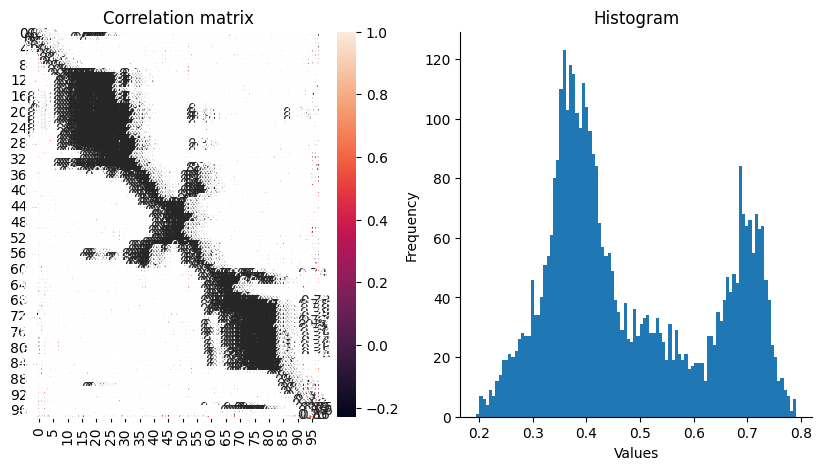

In [68]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
sns.heatmap(dfCCx.corr(),annot=True,ax=ax[0])
ax[0].set_title('Correlation matrix')

ax[1].hist(dfCCx.values.flatten(),bins=100)
ax[1].set_title('Histogram')
ax[1].set_xlabel('Values')
ax[1].set_ylabel('Frequency')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)


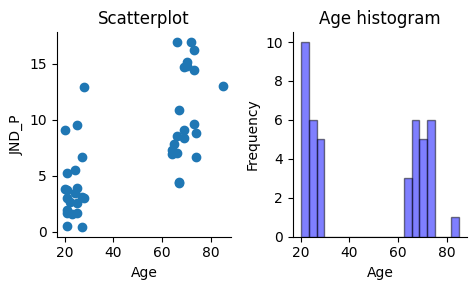

In [69]:

fig,ax=plt.subplots(1,2,figsize=(5,3))

ax[0].scatter(SubjectTable['age'],SubjectTable['JND_P'])
ax[0].set_title('Scatterplot')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('JND_P')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].hist(SubjectTable['age'],bins=20,color='blue',alpha=0.5,label='Age',edgecolor='black')
ax[1].set_title('Age histogram')
ax[1].set_xlabel('Age')
ax[1].set_ylabel('Frequency')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()

